# Fig: Infotaxis vs MAP comparison: pmax_th=0.95

Reference: 
- `20251027_infotaxis_vs_MP_cmp_random_target_across_pm_hist_2conditions_1e-5.ipynb`
- `20251214_fig_infotaxis_MAP_cmp.ipynb`: this 20251214 notebook uses pmax threshold=0.95; here in this notebook we use pmax threshold=0.99

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import seaborn as sns

In [2]:
from plot_utils import get_beam_search_space_ratio, consolidate_success_num_pings, get_stats
from simulation_data_prep import get_success_fname

In [3]:
cr = 5
br = 1
pmax_th = 0.95
pmax_diff_th = 1e-5
pm=0.05

path_data = Path("/Volumes/ssd_2tb_1/infotaxis_simu_2026")
path_left = path_data / "20260530_infotaxis_match_summary_compiled_pmax095_pmaxDiff1e-5"
path_right = path_data / "20260530_MAP_match_summary_compiled_pmax095_pmaxDiff1e-5"

In [4]:
# Load summary and ph details
df_x = pd.read_csv(
    path_left / get_success_fname(
        search_type="infotaxis",
        cr=cr,
        br=br,
        simulation_type="simple",
        pmax_th=pmax_th,
        pmax_diff_th=pmax_diff_th,
        pm_agent=pm
    ),
    index_col=0
)
df_y = pd.read_csv(
    path_right / get_success_fname(
        search_type="MAP",
        cr=cr,
        br=br,
        simulation_type="simple",
        pmax_th=pmax_th,
        pmax_diff_th=pmax_diff_th,
        pm_agent=pm
    ),
    index_col=0
)

In [5]:
# Filter df_left and df_right to include only runs that are successful in either criterion
# so num_pings_pmax_th and num_pings_pmax_diff cannot be -1
df_x_filter = consolidate_success_num_pings(df_x)
df_y_filter = consolidate_success_num_pings(df_y)

In [6]:
df_y_filter

,num_pings,num_grid_left,time_perf,time_proc,files_simu,num_pings_pmax_th,num_pings_pmax_diff,num_pings_run,success_pmax_th,success_pmax_diff,success_run,pmax_pmax_th,pmax_pmax_diff,pmax_run,h_actual_pmax_th,h_actual_pmax_diff,h_actual_run,success,num_pings_final
1,41,2,0.529370,0.527241,/scratch/ch153/wjl/infotaxis/runs/20251027/sim...,-1,36,40,False,True,True,NaN,0.468169,0.474321,NaN,1.376520,1.300123,True,36
2,41,3,0.525317,0.523087,/scratch/ch153/wjl/infotaxis/runs/20251027/sim...,-1,37,40,False,False,False,NaN,0.333247,0.333250,NaN,1.588098,1.587945,False,37
3,30,2,0.513095,0.510963,/scratch/ch153/wjl/infotaxis/runs/20251027/sim...,-1,18,29,False,True,True,NaN,0.439111,0.441279,NaN,1.560904,1.516063,True,18
4,38,3,0.519698,0.517570,/scratch/ch153/wjl/infotaxis/runs/20251027/sim...,-1,37,37,False,False,False,NaN,0.333252,0.333252,NaN,1.587866,1.587866,False,37
5,26,1,0.475495,0.473381,/scratch/ch153/wjl/infotaxis/runs/20251027/sim...,-1,23,25,False,False,False,NaN,0.874793,0.874794,NaN,0.767688,0.767671,False,23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
996,50,3,0.527595,0.524959,/scratch/ch153/wjl/infotaxis/runs/20251027/sim...,-1,48,49,False,False,False,NaN,0.333329,0.333329,NaN,1.585185,1.585184,False,48
997,39,2,0.521153,0.518985,/scratch/ch153/wjl/infotaxis/runs/20251027/sim...,-1,33,38,False,True,True,NaN,0.367722,0.367728,NaN,1.785599,1.785334,True,33
998,42,2,0.525824,0.523623,/scratch/ch153/wjl/infotaxis/runs/20251027/sim...,-1,35,41,False,True,True,NaN,0.422653,0.422689,NaN,1.559831,1.558578,True,35
999,34,3,0.513861,0.511772,/scratch/ch153/wjl/infotaxis/runs/20251027/sim...,-1,33,33,False,False,False,NaN,0.333299,0.333299,NaN,1.586318,1.586318,False,33


In [7]:
# Only cound successful runs
x = df_x_filter[df_x_filter["success"]]["num_pings_final"]
y = df_y_filter[df_y_filter["success"]]["num_pings_final"]

--------------------------------------------
Samples: left:  976    right:  501
Mean:    left: 21.679  right: 34.383
Median:  left: 20.000  right: 32.000

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000


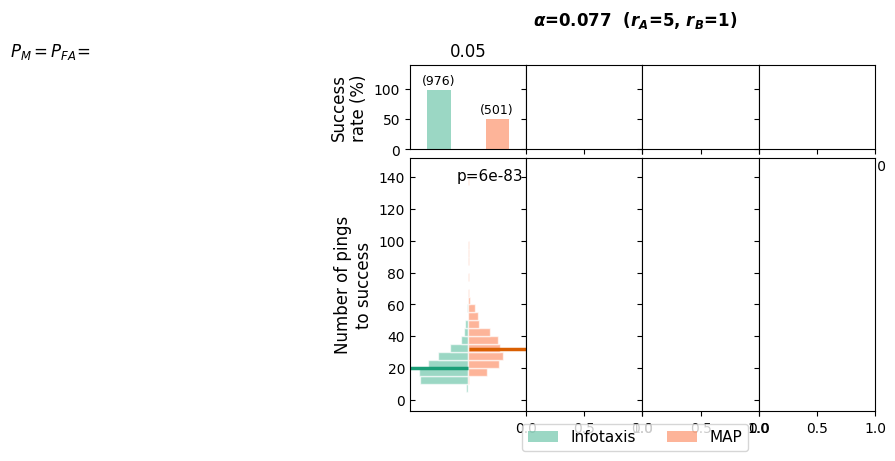

In [9]:
alpha = 0.65
idx = 0

# Get colors for plotting
colors = sns.color_palette("Set2")
colors_dark = sns.color_palette("Dark2")

# Plot
fig, axes = plt.subplots(
    2, 4, figsize=(6, 4.5), sharey="row",
    gridspec_kw={'height_ratios': [1, 3], 'hspace': 0.05, "wspace": 0}  # Top row is 1/3 height of bottom
)

# Print statistics
stats_dict = get_stats(x, y, print_stats=True)


# Plotting success rate
ax_s = axes[0, idx]
bar_x = ax_s.bar(-0.5, len(x)/1000*100, width=0.4, color=colors[0], alpha=alpha)
bar_y = ax_s.bar(0.5, len(y)/1000*100, width=0.4, color=colors[1], alpha=alpha)
ax_s.text(-0.5, len(x)/1000*100+5, (f"({len(x)})"), ha="center", va="bottom", fontsize=9)
ax_s.text(0.5, len(y)/1000*100+5, (f"({len(y)})"), ha="center", va="bottom", fontsize=9)
ax_s.set_xlim(-1, 1)
ax_s.set_ylim(0, 140)
ax_s.set_title(f"{pm}")


# Plotting number of pings to success
ping_bins = np.arange(0, np.ceil(np.hstack((x, y)).max())+10, 5)

ax_n = axes[1, idx]

x_hist, x_bins = np.histogram(x, bins=ping_bins, density=True)
y_hist, y_bins = np.histogram(y, bins=ping_bins, density=True)
x_median = np.median(x)
y_median = np.median(y)

ax_n.barh(x_bins[:-1], -x_hist, height=np.diff(x_bins), left=0, align="edge", edgecolor="w", color=colors[0], alpha=alpha)
ax_n.barh(y_bins[:-1], y_hist, height=np.diff(x_bins), left=0, align="edge", edgecolor="w", color=colors[1], alpha=alpha)        
ax_s.set_xticks([])
ax_s.set_xticklabels("")

# Get x-axis limits
xlim = ax_n.get_xlim()
xlim = np.max([max(xlim), -min(xlim)])
xlim = xlim + 0.1*np.max(xlim)
ax_n.set_xlim(-xlim, xlim)
ax_n.axhline(x_median, xmin=0.0, xmax=0.5, color=colors_dark[0], solid_capstyle="butt", lw=2.5)
ax_n.axhline(y_median, xmin=0.51, xmax=1, color=colors_dark[1], solid_capstyle="butt", lw=2.5)

# label sample number
ax_n.set_xticks([])
ax_n.set_xticklabels("")

# label p-value for alternative="less"
ax_n.text(
    0.975, 0.93, f"p={stats_dict["less"].pvalue:.0e}",
    ha="right", va="center",
    transform=ax_n.transAxes,
    fontsize=11, 
)

ax_n.tick_params(direction='in', which='both')
if idx != 0:
    if ping_bins[-1] > 200:
        ax_n.set_yticks(ping_bins[::8])
    else:
        ax_n.set_yticks(ping_bins[::4])

# make title line
axes[0, 0].text(
-2.75, 1.04, r"$P_M=P_{FA}$=",
ha="right", va="bottom",
transform=ax_s.transAxes,
fontsize=12,
)

alpha_grid = get_beam_search_space_ratio(cr, br)
axes[0, 0].set_ylabel("Success\nrate (%)", fontsize=12)    
axes[1, 0].set_ylabel("Number of pings\nto success", fontsize=12)
fig.text(0.5, 0.98, fr"$\mathbfit{{\alpha}}$={alpha_grid:.3f}  ($\mathbfit{{r_A}}$={cr}, $\mathbfit{{r_B}}$={br})",
    ha="center", va="center", fontsize=12, fontweight="bold")
# fig.text(0.5, 0.97, fr"Space radius={cr}, footprint radius={br} ($\alpha$={alpha_grid:.3f})",
#     ha="center", va="center", fontsize=12)

# Add single horizontal legend below all panels
fig.legend(
    handles=[bar_x, bar_y],
    labels=['Infotaxis', 'MAP'],
    loc='lower center',
    ncol=2,
    bbox_to_anchor=(0.5, 0.005),
    # frameon=False,
    fontsize=11
)    

# plt.tight_layout(pad=0)
plt.show()